# Phase 1 — Data Pipeline: PhysioNet/CinC 2016 Heart Sound Dataset

**Project:** XAI for Heart Sound Analysis (PCG Signals)  
**Team:** Urva Gandhi (23BCE078) & Rakshit Gajnotar (23BCE077)  
**Course:** RMS, Semester 6, Nirma University  
**Stage:** Review 2 — Implementation

---

**Pipeline Overview:**
1. Mount Google Drive & install dependencies
2. Download PhysioNet/CinC 2016 dataset (6 training subsets)
3. Load & merge labels → unified DataFrame
4. Preprocess audio: resample → bandpass filter → normalize → pad/trim
5. Generate Log-Mel Spectrograms → save as `.npy`
6. Build PyTorch DataLoaders (stratified 70/15/15 split)
7. Visualize & sanity check

## 0 — Setup

In [1]:
# Environment detection (Colab vs local) + Drive mount
# ─────────────────────────────────────────────────────────
# This cell makes the notebook portable. On Colab it mounts Drive at
# /content/drive; locally it just sets a flag — no mount needed.

def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

IS_COLAB = _is_colab()
print(f"Running on: {'Google Colab' if IS_COLAB else 'Local machine'}")

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted at /content/drive")


Running on: Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


In [2]:
# Install required packages — works on Colab AND local (pip via subprocess).
# Comment this cell out if your environment already has everything.
import sys, subprocess

REQUIRED = [
    "librosa", "scipy", "numpy", "pandas",
    "torch", "torchvision", "tqdm", "requests",
    "scikit-learn", "matplotlib", "seaborn",
]

def _missing():
    import importlib
    aliases = {"scikit-learn": "sklearn"}
    out = []
    for p in REQUIRED:
        mod = aliases.get(p, p)
        try:
            importlib.import_module(mod)
        except ImportError:
            out.append(p)
    return out

_to_install = _missing()
if _to_install:
    print(f"Installing: {_to_install}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_to_install])
else:
    print("All required packages already installed.")


All required packages already installed.


In [3]:
import os
import requests
import zipfile
import numpy as np
import pandas as pd
import librosa
import librosa.display
from scipy.signal import butter, filtfilt
from pathlib import Path
from tqdm.notebook import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
# ════════════════════════════════════════════
# PATH CONFIGURATION — works on Colab (Drive) or local machine
# ════════════════════════════════════════════
#
# Detection priority:
#   1. Manual override:  set BASE_OVERRIDE below to a custom path
#   2. Colab + Drive:    /content/drive/MyDrive/CSE/College/RMS
#   3. Local:            <repo_root>  (parent of the directory holding this notebook)
#
# Layout expected under BASE_DIR:
#   physionet_2016/
#     ├── raw/{training-a..f,validation}/*.wav
#     ├── spectrograms/*.npy        (generated by this notebook)
#     ├── metadata.csv              (generated by this notebook)
#     ├── split_indices.json        (generated by this notebook)
#     └── class_weights.pt          (generated by this notebook)

BASE_OVERRIDE = None   # e.g. "/content/drive/MyDrive/CSE/College/RMS"

DRIVE_DEFAULT = Path("/content/drive/MyDrive/CSE/College/RMS")

if BASE_OVERRIDE is not None:
    BASE_DIR = Path(BASE_OVERRIDE).expanduser().resolve()
elif IS_COLAB and DRIVE_DEFAULT.exists():
    BASE_DIR = DRIVE_DEFAULT
else:
    # Local: walk up from the current working directory until we find a folder
    # that already contains "physionet_2016/raw" (likely the repo root). Fall
    # back to the parent of CWD if nothing matches.
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    BASE_DIR = next(
        (p for p in candidates if (p / "physionet_2016" / "raw").exists()),
        cwd.parent,
    )

DATA_DIR = BASE_DIR / "physionet_2016"
RAW_DIR  = DATA_DIR / "raw"
SPEC_DIR = DATA_DIR / "spectrograms"

# Directory where the matplotlib figures generated below are saved.
# On Colab this writes back to Drive; locally it sits alongside this notebook.
FIG_DIR = (BASE_DIR / "Review 2" / "output") if not IS_COLAB else BASE_DIR
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR.mkdir(parents=True, exist_ok=True)
SPEC_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base directory : {BASE_DIR}")
print(f"Data directory : {DATA_DIR}")
print(f"Raw audio      : {RAW_DIR}  (exists: {RAW_DIR.exists()})")
print(f"Spectrograms   : {SPEC_DIR}  (exists: {SPEC_DIR.exists()})")
print(f"Figures dir    : {FIG_DIR}")


Base directory : /content/drive/MyDrive/CSE/College/RMS
Data directory : /content/drive/MyDrive/CSE/College/RMS/physionet_2016
Raw audio      : /content/drive/MyDrive/CSE/College/RMS/physionet_2016/raw  (exists: True)
Spectrograms   : /content/drive/MyDrive/CSE/College/RMS/physionet_2016/spectrograms  (exists: True)
Figures dir    : /content/drive/MyDrive/CSE/College/RMS


## 1 — Constants

In [5]:
# Audio preprocessing constants
SR_TARGET  = 4000    # Resample to 4 kHz (sufficient for heart sounds < 1 kHz)
DURATION   = 8.0     # Fixed clip length in seconds
N_FFT      = 512     # STFT window size
HOP_LENGTH = 128     # STFT hop length
N_MELS     = 128     # Number of Mel filterbanks
FMIN       = 20      # Min frequency (Hz)
FMAX       = 1000    # Max frequency (Hz)

# Training subsets (inside training.zip)
TRAINING_SUBSETS = [
    "training-a", "training-b", "training-c",
    "training-d", "training-e", "training-f"
]

# All subsets including validation
ALL_SUBSETS = TRAINING_SUBSETS + ["validation"]

# Backward compat
SUBSETS = TRAINING_SUBSETS

# PhysioNet URLs
TRAINING_ZIP_URL   = "https://physionet.org/files/challenge-2016/1.0.0/training.zip"
VALIDATION_ZIP_URL = "https://physionet.org/files/challenge-2016/1.0.0/validation.zip"

# Class names
CLASS_NAMES = ["Normal", "Abnormal"]

## 2 — Download Dataset

In [6]:
def download_dataset(data_dir=RAW_DIR):
    """
    Download PhysioNet/CinC 2016 dataset (training + validation).
    Downloads to Google Drive so you only need to do this ONCE.
    """
    data_dir.mkdir(parents=True, exist_ok=True)

    downloads = [
        ("Training",   TRAINING_ZIP_URL,   TRAINING_SUBSETS, "training.zip"),
        ("Validation", VALIDATION_ZIP_URL, ["validation"],   "validation.zip"),
    ]

    for name, url, subsets, zip_name in downloads:
        # Check if already extracted
        existing = [s for s in subsets if (data_dir / s).exists() and any((data_dir / s).glob("*.wav"))]

        if len(existing) == len(subsets):
            total = sum(len(list((data_dir / s).glob("*.wav"))) for s in subsets)
            print(f"  {name}: Already on Drive! ({total} wav files)")
            for s in subsets:
                n = len(list((data_dir / s).glob("*.wav")))
                print(f"    {s}: {n} files")
            continue

        # Download
        zip_path = data_dir / zip_name
        if not zip_path.exists():
            print(f"  Downloading {zip_name} ...", end=" ", flush=True)
            r = requests.get(url, stream=True)
            r.raise_for_status()
            with open(zip_path, "wb") as f:
                downloaded = 0
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
                    downloaded += len(chunk)
            print(f"({downloaded / 1e6:.1f} MB) done!")
        else:
            print(f"  {zip_name} found, extracting...")

        # Extract
        print(f"  Extracting {zip_name}...", end=" ", flush=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(data_dir)
        zip_path.unlink()
        print("done!")

    # Summary
    print(f"\n  Summary:")
    total_wavs = 0
    for s in ALL_SUBSETS:
        d = data_dir / s
        if d.exists():
            n = len(list(d.glob("*.wav")))
            total_wavs += n
            print(f"    {s}: {n} files")
    print(f"  Total: {total_wavs} wav files")

In [7]:
print("═" * 50)
print("STEP 1: Downloading PhysioNet/CinC 2016 Dataset")
print("═" * 50)
download_dataset()

══════════════════════════════════════════════════
STEP 1: Downloading PhysioNet/CinC 2016 Dataset
══════════════════════════════════════════════════
  Training: Already on Drive! (3240 wav files)
    training-a: 409 files
    training-b: 490 files
    training-c: 31 files
    training-d: 55 files
    training-e: 2141 files
    training-f: 114 files
  Validation: Already on Drive! (301 wav files)
    validation: 301 files

  Summary:
    training-a: 409 files
    training-b: 490 files
    training-c: 31 files
    training-d: 55 files
    training-e: 2141 files
    training-f: 114 files
    validation: 301 files
  Total: 3541 wav files


## 3 — Load & Merge Labels

In [8]:
def load_labels(data_dir=RAW_DIR, subsets=ALL_SUBSETS):
    """
    Read all REFERENCE.csv files (training + validation) into one DataFrame.
    PhysioNet 2016 convention: raw labels -1 = normal, 1 = abnormal
    (Clifford et al., 2016). Remap to 0 = Normal, 1 = Abnormal.
    Adds unique_id = subset_filename to avoid collisions (e.g., training-a_a0001).
    """
    rows = []
    for subset in subsets:
        ref_path = data_dir / subset / "REFERENCE.csv"
        if not ref_path.exists():
            print(f"  Warning: {ref_path} not found, skipping.")
            continue
        sub_df = pd.read_csv(ref_path, header=None, names=["filename", "label"])
        sub_df["subset"] = subset
        sub_df["wav_path"] = sub_df["filename"].apply(
            lambda f: str(data_dir / subset / f"{f}.wav")
        )
        sub_df["unique_id"] = subset + "_" + sub_df["filename"]
        rows.append(sub_df)

    df = pd.concat(rows, ignore_index=True)

    # Remap: -1 -> 0 (Normal), 1 -> 1 (Abnormal)  [PhysioNet 2016 convention]
    df["label"] = df["label"].map({-1: 0, 1: 1})

    # Drop any rows where wav file doesn't exist
    exists_mask = df["wav_path"].apply(lambda p: Path(p).exists())
    missing = (~exists_mask).sum()
    if missing > 0:
        print(f"  Warning: {missing} wav files missing, dropped.")
        df = df[exists_mask].reset_index(drop=True)

    print(f"  Unique IDs: {df['unique_id'].nunique()} (should equal {len(df)})")
    return df

In [9]:
print("=" * 50)
print("STEP 2: Loading Labels (Training + Validation)")
print("=" * 50)
df = load_labels()

# Use sort_index() to access by label value, NOT by frequency
label_counts = df["label"].value_counts().sort_index()
n_normal   = label_counts[0]
n_abnormal = label_counts[1]

print(f"\nTotal recordings: {len(df)}")
print(f"\nClass distribution:")
print(f"  Normal (0)  : {n_normal}  ({n_normal/len(df)*100:.1f}%)")
print(f"  Abnormal (1): {n_abnormal}  ({n_abnormal/len(df)*100:.1f}%)")
print(f"\nSubset breakdown:")
print(df.groupby("subset")["label"].value_counts().unstack(fill_value=0).rename(columns={0: "Normal", 1: "Abnormal"}))

# Correct ratio calculation
if n_normal > n_abnormal:
    print(f"\nImbalance ratio: {n_normal/n_abnormal:.2f} : 1 (Normal dominates)")
else:
    print(f"\nImbalance ratio: 1 : {n_abnormal/n_normal:.2f} (Abnormal dominates)")
    print(f"  Class weights will compensate for this during training")

STEP 2: Loading Labels (Training + Validation)
  Unique IDs: 3541 (should equal 3541)

Total recordings: 3541

Class distribution:
  Normal (0)  : 2725  (77.0%)
  Abnormal (1): 816  (23.0%)

Subset breakdown:
label       Normal  Abnormal
subset                      
training-a     117       292
training-b     386       104
training-c       7        24
training-d      27        28
training-e    1958       183
training-f      80        34
validation     150       151

Imbalance ratio: 3.34 : 1 (Normal dominates)


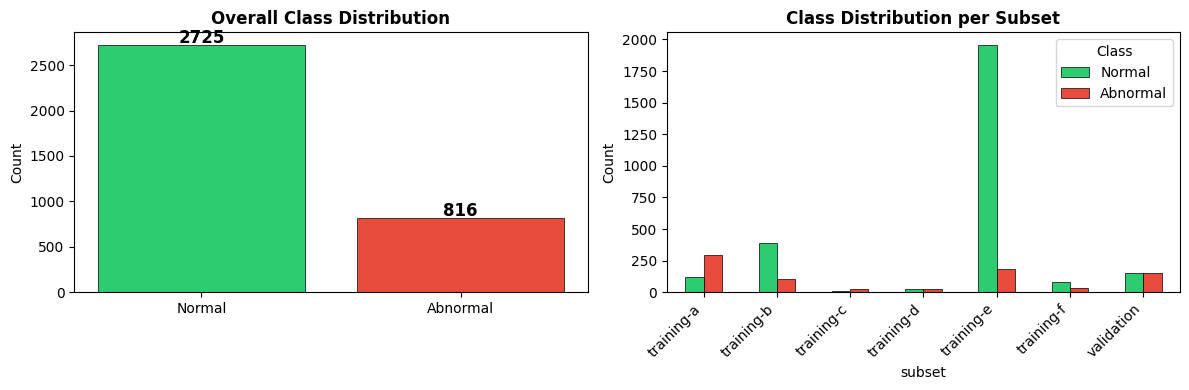

Saved: class_distribution.png


In [10]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
counts = df["label"].value_counts().sort_index()
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(CLASS_NAMES, counts.values, color=colors, edgecolor="black", linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title("Overall Class Distribution", fontweight='bold')
axes[0].set_ylabel("Count")

# Per-subset distribution
subset_counts = df.groupby("subset")["label"].value_counts().unstack(fill_value=0)
subset_counts.columns = CLASS_NAMES
subset_counts.plot(kind="bar", ax=axes[1], color=colors, edgecolor="black", linewidth=0.5)
axes[1].set_title("Class Distribution per Subset", fontweight='bold')
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(title="Class")

plt.tight_layout()
plt.savefig(str(FIG_DIR / "class_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

## 4 — Audio Preprocessing

In [11]:
def butter_bandpass(lowcut=25, highcut=900, fs=SR_TARGET, order=4):
    """4th-order Butterworth bandpass filter."""
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return b, a


def preprocess_audio(wav_path, sr_target=SR_TARGET, duration=DURATION):
    """
    Full preprocessing for one .wav file:
      1. Load + resample to 4000 Hz
      2. Butterworth bandpass filter (25-900 Hz)
      3. Normalize amplitude to [-1, 1]
      4. Pad or trim to fixed 8-second length
    """
    y, sr = librosa.load(str(wav_path), sr=sr_target, mono=True)

    # Bandpass filter
    b, a = butter_bandpass(fs=sr_target)
    y = filtfilt(b, a, y)

    # Normalize to [-1, 1]
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    # Pad or trim to fixed duration
    target_len = int(sr_target * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode="constant")
    else:
        y = y[:target_len]

    return y, sr_target


def audio_to_logmel(y, sr=SR_TARGET):
    """
    Convert preprocessed waveform → Log-Mel Spectrogram.
    Output shape: (128, ~250)
    """
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)

    # Normalize to [0, 1]
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)

    return log_mel.astype(np.float32)

### Visualize preprocessing pipeline on a single sample

Sample: a0001 | Label: Abnormal | Subset: training-a


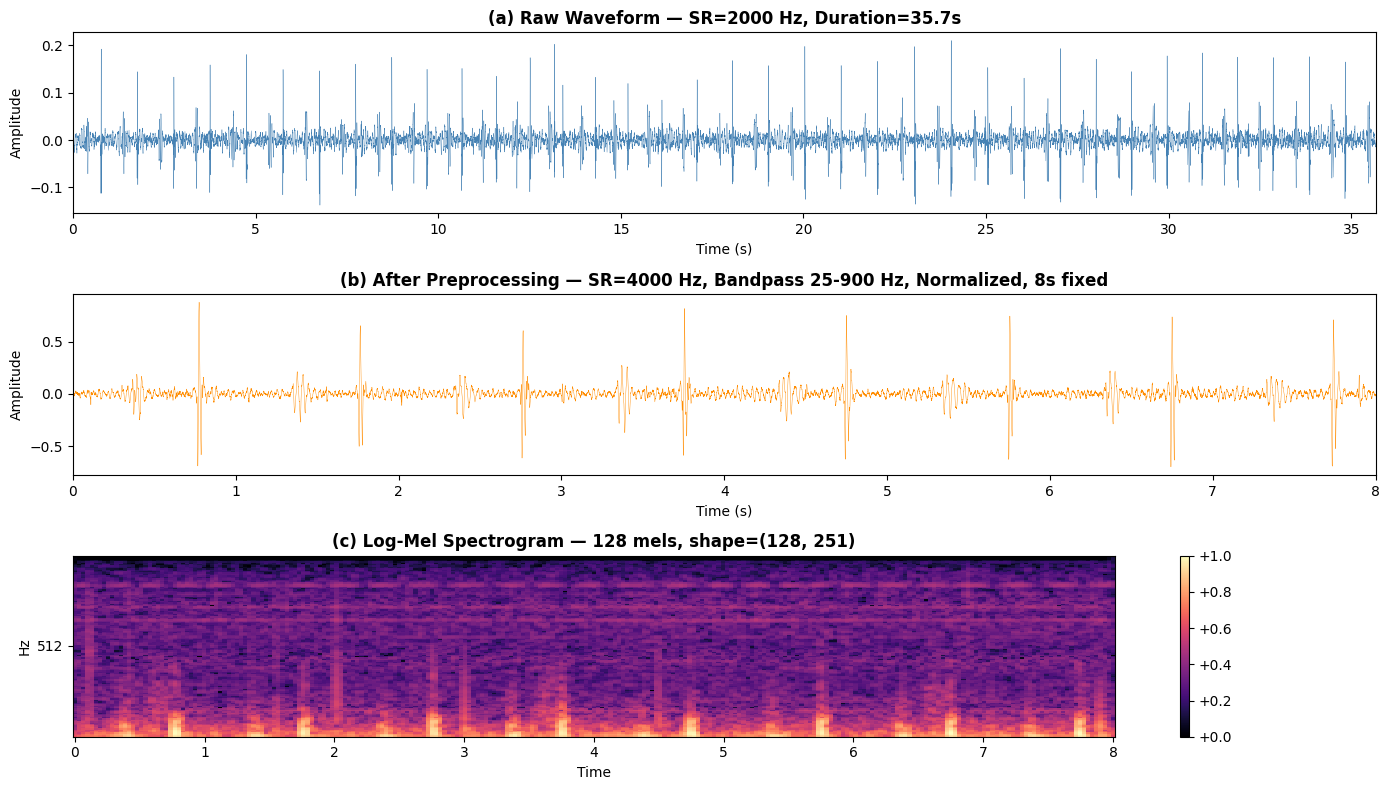

Saved: preprocessing_pipeline.png


In [12]:
# Pick one sample to show the full pipeline
sample_row = df.iloc[0]
print(f"Sample: {sample_row['filename']} | Label: {CLASS_NAMES[sample_row['label']]} | Subset: {sample_row['subset']}")

# Raw audio
y_raw, sr_raw = librosa.load(str(sample_row['wav_path']), sr=None, mono=True)

# Preprocessed audio
y_proc, sr_proc = preprocess_audio(sample_row['wav_path'])

# Spectrogram
spec = audio_to_logmel(y_proc, sr_proc)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Raw waveform
t_raw = np.arange(len(y_raw)) / sr_raw
axes[0].plot(t_raw, y_raw, linewidth=0.3, color='steelblue')
axes[0].set_title(f"(a) Raw Waveform — SR={sr_raw} Hz, Duration={len(y_raw)/sr_raw:.1f}s", fontweight='bold')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, t_raw[-1])

# Preprocessed waveform
t_proc = np.arange(len(y_proc)) / sr_proc
axes[1].plot(t_proc, y_proc, linewidth=0.3, color='darkorange')
axes[1].set_title(f"(b) After Preprocessing — SR={sr_proc} Hz, Bandpass 25-900 Hz, Normalized, 8s fixed", fontweight='bold')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlim(0, DURATION)

# Log-Mel Spectrogram
img = librosa.display.specshow(
    spec, sr=sr_proc, hop_length=HOP_LENGTH,
    x_axis='time', y_axis='mel', ax=axes[2],
    fmin=FMIN, fmax=FMAX, cmap='magma'
)
axes[2].set_title(f"(c) Log-Mel Spectrogram — {N_MELS} mels, shape={spec.shape}", fontweight='bold')
fig.colorbar(img, ax=axes[2], format='%+.1f')

plt.tight_layout()
plt.savefig(str(FIG_DIR / "preprocessing_pipeline.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: preprocessing_pipeline.png")

### Listen: Raw vs Preprocessed (Normal & Abnormal)

In [13]:
from IPython.display import display, Audio, HTML

PLAYBACK_SR = 22050  # Resample for smooth browser playback

# Pick one normal and one abnormal sample
normal_row   = df[df["label"] == 0].sample(1, random_state=42).iloc[0]
abnormal_row = df[df["label"] == 1].sample(1, random_state=42).iloc[0]

for label_name, row, color in [("Normal", normal_row, "#2ecc71"), ("Abnormal", abnormal_row, "#e74c3c")]:

    display(HTML(f"<h3 style='color:{color}; margin-bottom:2px'>{label_name} -- {row['filename']} ({row['subset']})</h3>"))

    # --- Raw audio (original) ---
    y_raw, sr_raw = librosa.load(str(row['wav_path']), sr=PLAYBACK_SR, mono=True)
    display(HTML(f"<b>Raw audio</b> (original recording, {len(y_raw)/PLAYBACK_SR:.1f}s):"))
    display(Audio(y_raw, rate=PLAYBACK_SR))

    # --- Preprocessed audio (4 kHz, bandpass, normalize, 8s fixed) ---
    y_proc, sr_proc = preprocess_audio(row['wav_path'])
    y_proc_play = librosa.resample(y_proc, orig_sr=sr_proc, target_sr=PLAYBACK_SR)
    display(HTML(f"<b>After preprocessing</b> (bandpass 25-900 Hz, normalized, 8s fixed):"))
    display(Audio(y_proc_play, rate=PLAYBACK_SR))

    display(HTML("<hr>"))

Output hidden; open in https://colab.research.google.com to view.

## 5 -- Generate & Save All Spectrograms

In [14]:
def process_and_save(df, spec_dir=SPEC_DIR):
    """
    Process all recordings -> save spectrograms as .npy.
    Uses unique_id (subset_filename) to avoid collisions.
    """
    spec_dir.mkdir(parents=True, exist_ok=True)

    existing = set(p.stem for p in spec_dir.glob("*.npy"))
    needed = set(df["unique_id"].values)
    missing = needed - existing

    if len(missing) == 0:
        print(f"  All {len(needed)} spectrograms already exist on Drive! Skipping.")
        print(f"  Location: {spec_dir}")
        return []

    print(f"  Found {len(existing & needed)} existing, need to process {len(missing)} more.")

    failed = []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing audio -> spectrograms"):
        out_path = spec_dir / f"{row['unique_id']}.npy"
        if out_path.exists():
            skipped += 1
            continue

        try:
            y, sr = preprocess_audio(row["wav_path"])
            spec = audio_to_logmel(y, sr)
            np.save(out_path, spec)
        except Exception as e:
            failed.append((row["unique_id"], str(e)))

    total_saved = len(list(spec_dir.glob('*.npy')))
    print(f"\nDone! Total spectrograms: {total_saved} | Skipped: {skipped} | Failed: {len(failed)}")

    if failed:
        print(f"\nFailed files:")
        for name, err in failed[:10]:
            print(f"  {name}: {err}")

    return failed


In [15]:
print("=" * 50)
print("STEP 3: Processing Audio -> Log-Mel Spectrograms")
print("=" * 50)
print(f"Output directory: {SPEC_DIR}")
print(f"Total recordings: {len(df)}")
print(f"(Skips files that already exist on Drive)\n")

failed_files = process_and_save(df)

# Verify: filter out any rows where spectrogram was not created
df["spec_exists"] = df["unique_id"].apply(lambda uid: (SPEC_DIR / f"{uid}.npy").exists())
missing_specs = df[~df["spec_exists"]]

if len(missing_specs) > 0:
    print(f"Warning: {len(missing_specs)} recordings have no spectrogram. Dropping them.")
    df = df[df["spec_exists"]].reset_index(drop=True)
else:
    print(f"All {len(df)} spectrograms verified.")

df = df.drop(columns=["spec_exists"])
print(f"Final dataset size: {len(df)}")

STEP 3: Processing Audio -> Log-Mel Spectrograms
Output directory: /content/drive/MyDrive/CSE/College/RMS/physionet_2016/spectrograms
Total recordings: 3541
(Skips files that already exist on Drive)

  All 3541 spectrograms already exist on Drive! Skipping.
  Location: /content/drive/MyDrive/CSE/College/RMS/physionet_2016/spectrograms
All 3541 spectrograms verified.
Final dataset size: 3541


## 6 — PyTorch Dataset & DataLoaders

In [16]:
class HeartSoundDataset(Dataset):
    """
    PyTorch Dataset for pre-saved .npy spectrograms.
    - Resizes to 224x224 (ResNet50 input)
    - Replicates to 3 channels (RGB)
    - Applies ImageNet normalization
    - Optional SpecAugment-style augmentation
    """

    IMG_SIZE = 224

    def __init__(self, df, spec_dir=SPEC_DIR, augment=False):
        self.df = df.reset_index(drop=True)
        self.spec_dir = Path(spec_dir)
        self.augment = augment
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec_path = self.spec_dir / f"{row['unique_id']}.npy" # Changed from row['filename']

        # Load spectrogram (128, T)
        spec = np.load(spec_path)

        # Resize to 224x224
        spec_tensor = torch.from_numpy(spec).unsqueeze(0).unsqueeze(0)  # (1, 1, 128, T)
        spec_tensor = torch.nn.functional.interpolate(
            spec_tensor,
            size=(self.IMG_SIZE, self.IMG_SIZE),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)  # (1, 224, 224)

        # Replicate to 3 channels
        spec_tensor = spec_tensor.repeat(3, 1, 1)  # (3, 224, 224)

        # ImageNet normalization
        spec_tensor = self.normalize(spec_tensor)

        # Augmentation (training only)
        if self.augment:
            spec_tensor = self._augment(spec_tensor)

        label = torch.tensor(row["label"], dtype=torch.long)
        return spec_tensor, label

    def _augment(self, x):
        """SpecAugment-style frequency + time masking."""
        # Frequency masking
        f_start = np.random.randint(0, self.IMG_SIZE - 20)
        f_width = np.random.randint(5, 20)
        x[:, f_start:f_start + f_width, :] = 0

        # Time masking
        t_start = np.random.randint(0, self.IMG_SIZE - 30)
        t_width = np.random.randint(10, 30)
        x[:, :, t_start:t_start + t_width] = 0

        return x

In [17]:
from sklearn.model_selection import train_test_split

def get_dataloaders(df, spec_dir=SPEC_DIR, batch_size=32,
                    val_split=0.15, test_split=0.15, seed=42):
    """
    Stratified train/val/test split → DataLoaders.
    Split ratio: 70% train / 15% val / 15% test
    """
    # Split: train vs (val + test)
    train_df, temp_df = train_test_split(
        df, test_size=val_split + test_split,
        stratify=df["label"], random_state=seed
    )
    # Split: val vs test
    relative_test = test_split / (val_split + test_split)
    val_df, test_df = train_test_split(
        temp_df, test_size=relative_test,
        stratify=temp_df["label"], random_state=seed
    )

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"Train class dist: {dict(train_df['label'].value_counts().sort_index())}")
    print(f"Val   class dist: {dict(val_df['label'].value_counts().sort_index())}")
    print(f"Test  class dist: {dict(test_df['label'].value_counts().sort_index())}")

    train_ds = HeartSoundDataset(train_df, spec_dir, augment=True)
    val_ds   = HeartSoundDataset(val_df,   spec_dir, augment=False)
    test_ds  = HeartSoundDataset(test_df,  spec_dir, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, train_df, val_df, test_df

In [18]:
print("═" * 50)
print("STEP 4: Building DataLoaders")
print("═" * 50)

if df.empty:
    print("Error: DataFrame 'df' is empty. Please ensure that cells 'cell-13' (Load & Merge Labels) and 'cell-23' (Generate & Save All Spectrograms) have been executed successfully.")
else:
    train_loader, val_loader, test_loader, train_df, val_df, test_df = get_dataloaders(df, SPEC_DIR)

══════════════════════════════════════════════════
STEP 4: Building DataLoaders
══════════════════════════════════════════════════
Train: 2478 | Val: 531 | Test: 532
Train class dist: {0: np.int64(1907), 1: np.int64(571)}
Val   class dist: {0: np.int64(409), 1: np.int64(122)}
Test  class dist: {0: np.int64(409), 1: np.int64(123)}


In [19]:
# Verify one batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch tensor shape : {X_batch.shape}")    # (32, 3, 224, 224)
print(f"Batch dtype        : {X_batch.dtype}")
print(f"Batch value range  : [{X_batch.min():.3f}, {X_batch.max():.3f}]")
print(f"Labels             : {y_batch.tolist()[:10]}...")
print(f"\nBatches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batch tensor shape : torch.Size([32, 3, 224, 224])
Batch dtype        : torch.float32
Batch value range  : [-2.118, 2.637]
Labels             : [0, 0, 0, 0, 0, 1, 1, 1, 0, 0]...

Batches — Train: 78 | Val: 17 | Test: 17


## 7 — Visualization & Sanity Checks

In [20]:
def visualise_samples(df, spec_dir=SPEC_DIR, n_per_class=4):
    """Plot spectrograms for both classes side by side."""
    fig, axes = plt.subplots(2, n_per_class, figsize=(16, 6))

    for row_idx, (label, label_name) in enumerate(zip([0, 1], CLASS_NAMES)):
        samples = df[df["label"] == label].sample(n_per_class, random_state=42)
        for col_idx, (_, row) in enumerate(samples.iterrows()):
            spec = np.load(spec_dir / f"{row['unique_id']}.npy") # Corrected to use unique_id
            ax = axes[row_idx, col_idx]
            img = librosa.display.specshow(
                spec, sr=SR_TARGET, hop_length=HOP_LENGTH,
                x_axis='time', y_axis='mel', ax=ax,
                fmin=FMIN, fmax=FMAX, cmap='magma'
            )
            color = '#2ecc71' if label == 0 else '#e74c3c'
            ax.set_title(f"{row['filename']}\n{label_name}", fontsize=9, color=color, fontweight='bold')
            if col_idx > 0:
                ax.set_ylabel('')
            if row_idx == 0:
                ax.set_xlabel('')

    plt.suptitle("Log-Mel Spectrograms — Normal (top) vs Abnormal (bottom)", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(str(FIG_DIR / "sample_spectrograms.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: sample_spectrograms.png")

══════════════════════════════════════════════════
STEP 5: Visualization
══════════════════════════════════════════════════


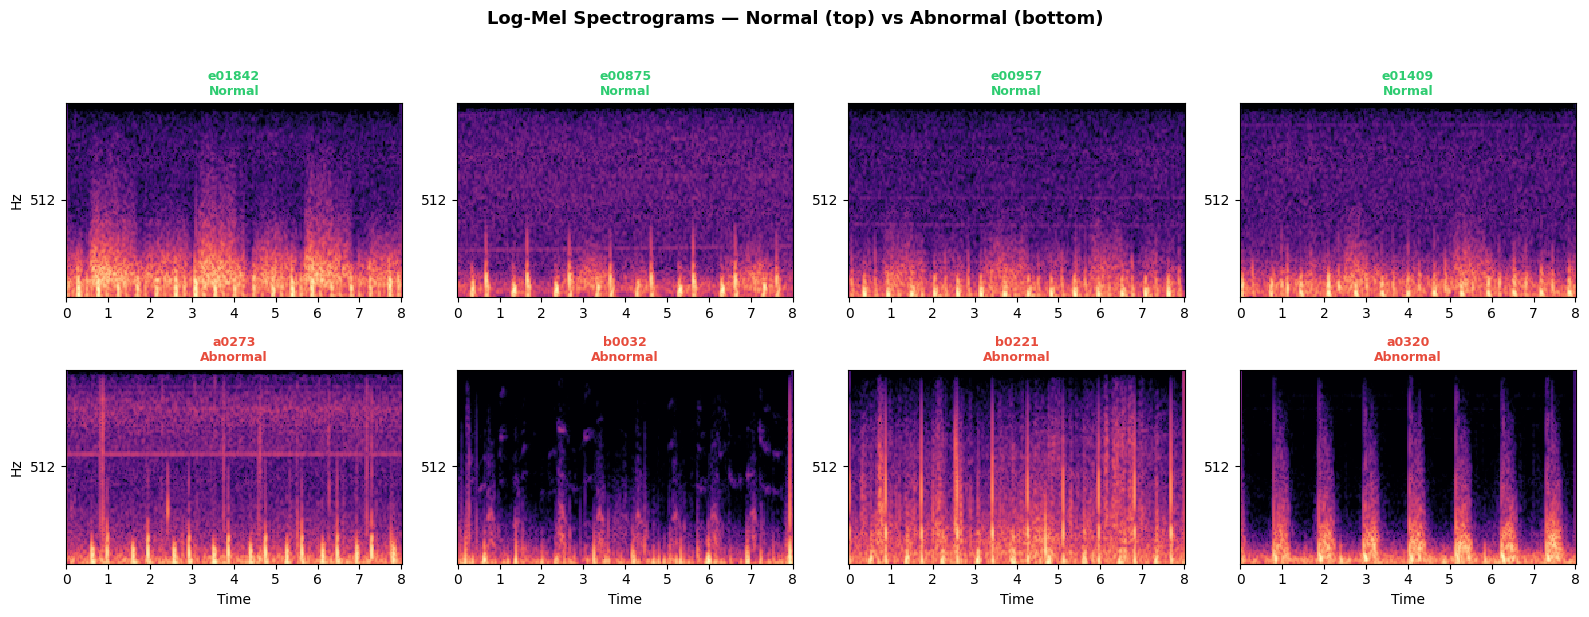

Saved: sample_spectrograms.png


In [21]:
print("═" * 50)
print("STEP 5: Visualization")
print("═" * 50)
visualise_samples(df, SPEC_DIR)

In [22]:
# Spectrogram statistics across the dataset
print("Computing spectrogram statistics (sampling 200 files)...")
sample_files = df.sample(min(200, len(df)), random_state=42)
shapes = []
means = []
stds = []

for _, row in sample_files.iterrows():
    spec = np.load(SPEC_DIR / f"{row['unique_id']}.npy")
    shapes.append(spec.shape)
    means.append(spec.mean())
    stds.append(spec.std())

unique_shapes = set(shapes)
print(f"\nUnique spectrogram shapes: {unique_shapes}")
print(f"Mean pixel value: {np.mean(means):.4f} +/- {np.std(means):.4f}")
print(f"Std pixel value:  {np.mean(stds):.4f} +/- {np.std(stds):.4f}")

Computing spectrogram statistics (sampling 200 files)...

Unique spectrogram shapes: {(128, 251)}
Mean pixel value: 0.2968 +/- 0.0913
Std pixel value:  0.1826 +/- 0.0303


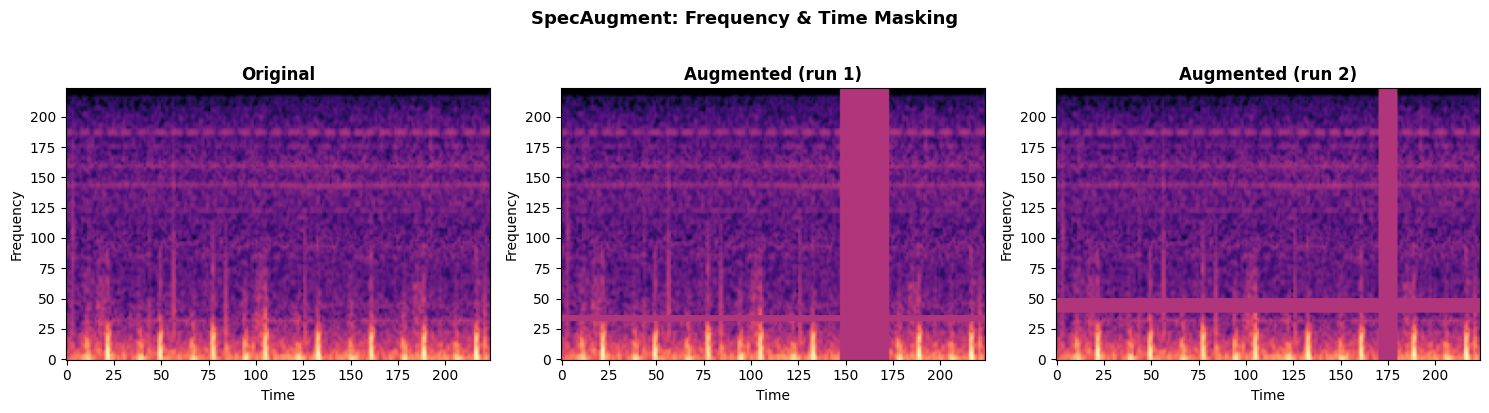

Saved: augmentation_demo.png


In [23]:
# Visualize augmentation effect
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get one sample from the dataset (without augmentation)
ds_no_aug = HeartSoundDataset(df.iloc[:1], SPEC_DIR, augment=False)
ds_aug    = HeartSoundDataset(df.iloc[:1], SPEC_DIR, augment=True)

orig, _ = ds_no_aug[0]
aug1, _ = ds_aug[0]
aug2, _ = ds_aug[0]

for ax, tensor, title in zip(axes, [orig, aug1, aug2],
                              ["Original", "Augmented (run 1)", "Augmented (run 2)"]):
    # Show channel 0 (denormalized for display)
    img = tensor[0].numpy()
    ax.imshow(img, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency")

plt.suptitle("SpecAugment: Frequency & Time Masking", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "augmentation_demo.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: augmentation_demo.png")

## 7.1 -- Advanced EDA & Signal Analysis

### (a) Recording Duration Distribution
Shows the spread of raw audio lengths across the dataset -- justifies our choice of 8-second fixed-length padding/trimming.

Computing recording durations...


Reading durations:   0%|          | 0/3541 [00:00<?, ?it/s]

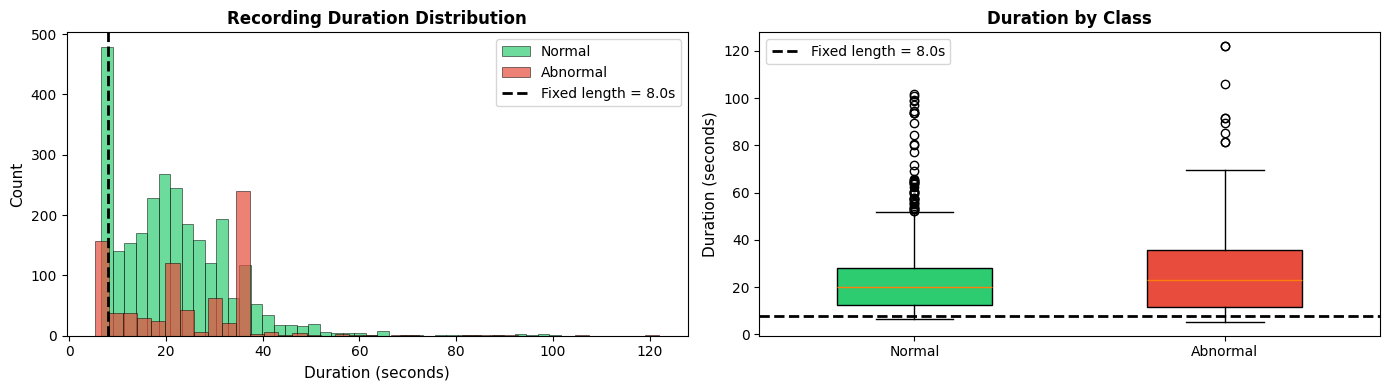


Duration statistics:
  Min: 5.3s | Max: 122.0s | Mean: 22.3s | Median: 20.8s
  Recordings trimmed (>8.0s): 83.2%
  Recordings padded  (<8.0s): 0.6%
Saved: duration_distribution.png


In [24]:
# Recording duration distribution
print("Computing recording durations...")
durations = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Reading durations"):
    try:
        dur = librosa.get_duration(path=str(row['wav_path']))
        durations.append(dur)
    except:
        durations.append(np.nan)

df["duration"] = durations

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df[df["label"]==0]["duration"].dropna(), bins=40, alpha=0.7, color="#2ecc71", label="Normal", edgecolor="black", linewidth=0.5)
axes[0].hist(df[df["label"]==1]["duration"].dropna(), bins=40, alpha=0.7, color="#e74c3c", label="Abnormal", edgecolor="black", linewidth=0.5)
axes[0].axvline(x=DURATION, color='black', linestyle='--', linewidth=2, label=f'Fixed length = {DURATION}s')
axes[0].set_xlabel("Duration (seconds)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Recording Duration Distribution", fontweight='bold')
axes[0].legend()

# Box plot per class
box_data = [df[df["label"]==0]["duration"].dropna(), df[df["label"]==1]["duration"].dropna()]
bp = axes[1].boxplot(box_data, labels=CLASS_NAMES, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].axhline(y=DURATION, color='black', linestyle='--', linewidth=2, label=f'Fixed length = {DURATION}s')
axes[1].set_ylabel("Duration (seconds)", fontsize=11)
axes[1].set_title("Duration by Class", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(FIG_DIR / "duration_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

# Statistics
print(f"\nDuration statistics:")
print(f"  Min: {df['duration'].min():.1f}s | Max: {df['duration'].max():.1f}s | Mean: {df['duration'].mean():.1f}s | Median: {df['duration'].median():.1f}s")
pct_trimmed = (df['duration'] > DURATION).mean() * 100
pct_padded  = (df['duration'] < DURATION).mean() * 100
print(f"  Recordings trimmed (>{DURATION}s): {pct_trimmed:.1f}%")
print(f"  Recordings padded  (<{DURATION}s): {pct_padded:.1f}%")
print("Saved: duration_distribution.png")

### (b) Butterworth Bandpass Filter -- Frequency Response
Visualizes the filter's gain curve to show exactly which frequencies are kept (25-900 Hz) and which are attenuated.

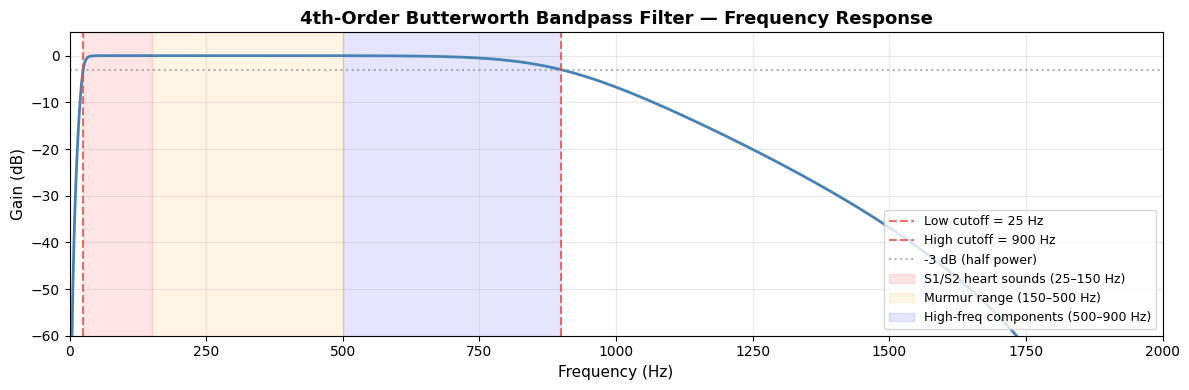

Saved: filter_response.png


In [25]:
from scipy.signal import freqz

b, a = butter_bandpass(lowcut=25, highcut=900, fs=SR_TARGET, order=4)
w, h = freqz(b, a, worN=2000, fs=SR_TARGET)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(w, 20 * np.log10(np.abs(h) + 1e-10), color='steelblue', linewidth=2)

# Mark passband
ax.axvline(25,  color='#e74c3c', linestyle='--', alpha=0.8, label='Low cutoff = 25 Hz')
ax.axvline(900, color='#e74c3c', linestyle='--', alpha=0.8, label='High cutoff = 900 Hz')
ax.axhline(-3,  color='gray',    linestyle=':',  alpha=0.6, label='-3 dB (half power)')

# Annotate cardiac frequency bands
ax.axvspan(25,  150,  alpha=0.1, color='red',    label='S1/S2 heart sounds (25–150 Hz)')
ax.axvspan(150, 500,  alpha=0.1, color='orange', label='Murmur range (150–500 Hz)')
ax.axvspan(500, 900,  alpha=0.1, color='blue',   label='High-freq components (500–900 Hz)')

ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Gain (dB)', fontsize=11)
ax.set_title('4th-Order Butterworth Bandpass Filter — Frequency Response', fontweight='bold', fontsize=13)
ax.set_xlim(0, SR_TARGET / 2)
ax.set_ylim(-60, 5)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(FIG_DIR / "filter_response.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: filter_response.png")

### (c) Heart Sound Envelope & S1/S2 Peak Detection
Uses the Hilbert transform to extract the amplitude envelope, then detects peaks corresponding to S1 (lub) and S2 (dub) heart sounds.

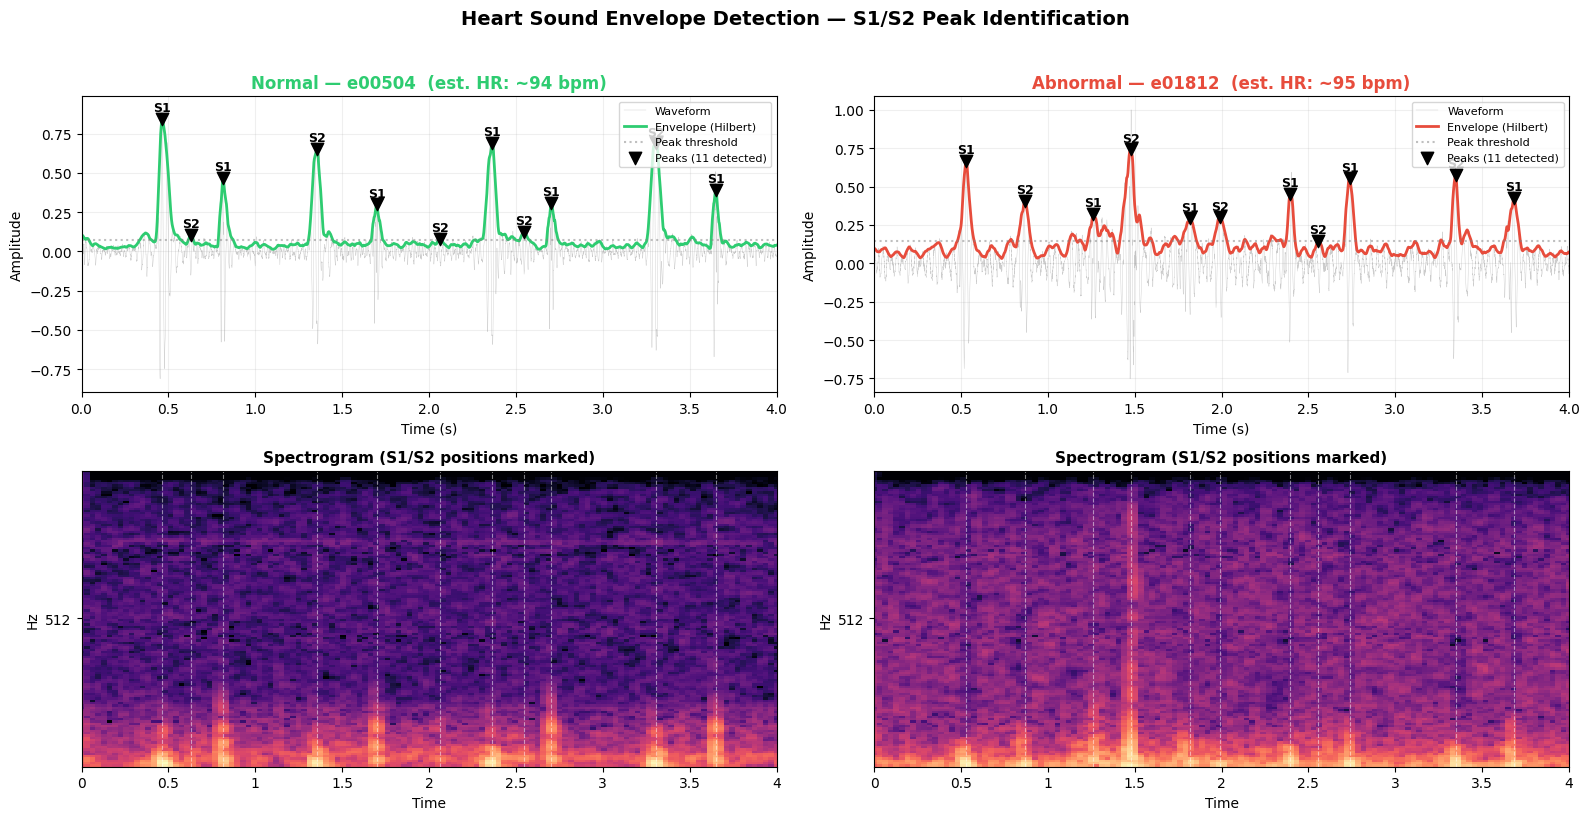

Saved: envelope_detection.png


In [26]:
from scipy.signal import hilbert, find_peaks
from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for col, (label, label_name, color) in enumerate([(0, "Normal", "#2ecc71"), (1, "Abnormal", "#e74c3c")]):
    sample = df[df["label"] == label].sample(1, random_state=7).iloc[0]
    y, sr = preprocess_audio(sample["wav_path"])

    # Use first 4 seconds for clearer visualization
    t_end = 4.0
    n_end = int(t_end * sr)
    y_clip = y[:n_end]
    t = np.arange(n_end) / sr

    # Hilbert envelope
    analytic = hilbert(y_clip)
    envelope = np.abs(analytic)
    # Smooth envelope with wider window for cleaner peaks
    envelope_smooth = uniform_filter1d(envelope, size=int(0.03 * sr))

    # Adaptive peak detection — threshold relative to signal, not fixed
    peak_height = np.percentile(envelope_smooth, 70)  # adaptive threshold
    peak_dist = int(0.15 * sr)  # min 150ms between peaks (allows up to ~200 bpm)
    peaks, properties = find_peaks(
        envelope_smooth,
        height=peak_height,
        distance=peak_dist,
        prominence=0.03  # lower prominence to catch quieter peaks
    )

    # Estimate heart rate from peaks
    if len(peaks) > 1:
        avg_interval = np.mean(np.diff(t[peaks]))
        # S1-S2 pairs: every 2 peaks = 1 heartbeat
        est_hr = 60 / (avg_interval * 2) if avg_interval > 0 else 0
    else:
        est_hr = 0

    # --- Waveform + Envelope + Peaks ---
    ax = axes[0, col]
    ax.plot(t, y_clip, linewidth=0.3, alpha=0.4, color='gray', label='Waveform')
    ax.plot(t, envelope_smooth, linewidth=2, color=color, label='Envelope (Hilbert)')
    ax.axhline(y=peak_height, color='gray', linestyle=':', alpha=0.5, label=f'Peak threshold')
    ax.scatter(t[peaks], envelope_smooth[peaks], color='black', s=80, zorder=5,
               marker='v', label=f'Peaks ({len(peaks)} detected)')
    # Annotate S1/S2 alternating
    for i, pk in enumerate(peaks):
        s_label = "S1" if i % 2 == 0 else "S2"
        ax.annotate(s_label, (t[pk], envelope_smooth[pk] + 0.05),
                    ha='center', fontsize=9, fontweight='bold', color='black')
    ax.set_title(f'{label_name} — {sample["filename"]}  (est. HR: ~{est_hr:.0f} bpm)',
                 fontweight='bold', color=color, fontsize=12)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, t_end)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2)

    # --- Corresponding Spectrogram ---
    spec = audio_to_logmel(y, sr)
    ax2 = axes[1, col]
    librosa.display.specshow(spec, sr=sr, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', ax=ax2,
                             fmin=FMIN, fmax=FMAX, cmap='magma')
    # Draw peak positions on spectrogram
    for pk in peaks:
        ax2.axvline(x=t[pk], color='white', linestyle='--', alpha=0.5, linewidth=0.8)
    ax2.set_title(f'Spectrogram (S1/S2 positions marked)', fontweight='bold', fontsize=11)
    ax2.set_xlim(0, t_end)

plt.suptitle('Heart Sound Envelope Detection — S1/S2 Peak Identification',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(FIG_DIR / "envelope_detection.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: envelope_detection.png")

## 8 — Save Metadata for Phase 2

In [27]:
# Save the DataFrame for use in Phase 2 (model training)
# Store wav_path as RELATIVE for portability across machines
df_save = df.copy()
df_save["wav_path"] = df_save.apply(
    lambda row: f"{row['subset']}/{row['filename']}.wav", axis=1
)
# Drop duration column (can be recomputed)
if "duration" in df_save.columns:
    df_save = df_save.drop(columns=["duration"])

metadata_path = DATA_DIR / "metadata.csv"
df_save.to_csv(metadata_path, index=False)
print(f"Saved metadata: {metadata_path}")
print(f"  wav_path stored as RELATIVE paths (e.g., '{df_save['wav_path'].iloc[0]}')")

# Save split indices for reproducibility
split_info = {
    "train_indices": train_df.index.tolist(),
    "val_indices":   val_df.index.tolist(),
    "test_indices":  test_df.index.tolist(),
}
import json as json_lib
split_path = DATA_DIR / "split_indices.json"
with open(split_path, "w") as f:
    json_lib.dump(split_info, f)
print(f"Saved split indices: {split_path}")

Saved metadata: /content/drive/MyDrive/CSE/College/RMS/physionet_2016/metadata.csv
  wav_path stored as RELATIVE paths (e.g., 'training-a/a0001.wav')
Saved split indices: /content/drive/MyDrive/CSE/College/RMS/physionet_2016/split_indices.json


In [28]:
# Compute and save class weights for Phase 2 training
label_counts = df["label"].value_counts().sort_index()
class_weights = 1.0 / label_counts.values.astype(np.float32)
class_weights = class_weights / class_weights.sum()  # normalize
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print(f"Label counts     : {dict(label_counts)}")
print(f"Class weights    : {class_weights}")
print(f"Weights (tensor) : {class_weights_tensor}")

torch.save(class_weights_tensor, str(DATA_DIR / "class_weights.pt"))
print(f"\nSaved: {DATA_DIR / 'class_weights.pt'}")

Label counts     : {0: np.int64(2725), 1: np.int64(816)}
Class weights    : [0.23044337 0.76955664]
Weights (tensor) : tensor([0.2304, 0.7696])

Saved: /content/drive/MyDrive/CSE/College/RMS/physionet_2016/class_weights.pt


## Summary

Phase 1 complete. Files saved to Google Drive:

```
/content/drive/MyDrive/CSE/College/RMS/
  physionet_2016/
    raw/                       .wav files (training-a to training-f + validation)
    spectrograms/              .npy log-mel spectrograms
    metadata.csv               filename, label, subset, wav_path (relative)
    split_indices.json         train/val/test indices for reproducibility
    class_weights.pt           inverse-frequency weights for CrossEntropyLoss
  class_distribution.png
  preprocessing_pipeline.png
  sample_spectrograms.png
  augmentation_demo.png
  duration_distribution.png
  filter_response.png
  psd_comparison.png
  envelope_detection.png
  tsne_spectrograms.png
```

**Dataset:** 3,240 training + 301 validation = **3,541 total recordings**

Ready for **Phase 2** (Model Architecture + Training).